# Y Combinator Company Growth Rate Analysis

This notebook explores the change in growth rates amongst Y Combinator companies started in different years.

## Objectives:
- Analyze valuation growth patterns across different YC batch years
- Compare growth trajectories of companies from different eras
- Identify trends in startup valuations over time
- Examine the impact of market conditions on YC company growth

In [51]:
!pip install pandas numpy matplotlib seaborn jupyter


[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("📊 Libraries loaded successfully")

📊 Libraries loaded successfully


## 1. Data Loading and Exploration

In [53]:
# Connect to the SQLite database and load data
conn = sqlite3.connect('yc_valuations.db')

# Load companies data
companies_df = pd.read_sql_query("""
    SELECT company, batch, yc_year, status, final_year, end_reason
    FROM companies
    WHERE status = 'completed'
""", conn)

# Load valuations data with company info
valuations_df = pd.read_sql_query("""
    SELECT v.company, v.year, v.valuation, v.source, v.notes,
           c.yc_year, c.batch, c.final_year, c.end_reason
    FROM valuations v
    JOIN companies c ON v.company = c.company
    WHERE c.status = 'completed'
    ORDER BY c.yc_year, v.company, v.year
""", conn)

conn.close()

print(f"📈 Loaded data for {len(companies_df)} companies")
print(f"📊 Total valuations: {len(valuations_df)}")
print(f"🗓️  YC years range: {companies_df['yc_year'].min()} - {companies_df['yc_year'].max()}")

📈 Loaded data for 574 companies
📊 Total valuations: 4684
🗓️  YC years range: 2005 - 2015


In [54]:
# Display basic info about the dataset
print("Companies by YC Year:")
print(companies_df['yc_year'].value_counts().sort_index().head(10))

print("\nEnd Reasons:")
print(companies_df['end_reason'].value_counts())

print("\nSample of valuations data:")
display(valuations_df.head())

Companies by YC Year:
yc_year
2005      8
2006     18
2007     30
2008     31
2009     31
2010     50
2011     86
2012    124
2013     86
2014     99
Name: count, dtype: int64

End Reasons:
end_reason
still_operating                     235
acquired                            173
shutdown                            104
insufficient_information              3
insufficient_data                     3
significant downsizing                1
transformed into another company      1
bankrupt                              1
bankruptcy                            1
inactive                              1
unable_to_verify                      1
pivoted                               1
Name: count, dtype: int64

Sample of valuations data:


,company,year,valuation,source,notes,yc_year,batch,final_year,end_reason
0,Clickfacts,2005,YC investment (estimated $6-25K for 6-7% equity),https://www.ycombinator.com/companies/clickfacts,"Founded 2005, Y Combinator Summer 2005 batch i...",2005,Summer 2005,NaN,None
1,Clickfacts,2006,Not found,Various searches conducted,No specific valuation data found for 2006,2005,Summer 2005,NaN,None
2,Clickfacts,2007,Company ceased operations (July 2007),https://www.boringbusinessnerd.com/post/y-comb...,Company stopped operating in July 2007 when co...,2005,Summer 2005,NaN,None
3,Clickfacts,2008,Not operating,https://www.boringbusinessnerd.com/post/y-comb...,Company had already ceased operations in 2007,2005,Summer 2005,NaN,None
4,Clickfacts,2009,Not operating,https://www.boringbusinessnerd.com/post/y-comb...,Company had already ceased operations in 2007,2005,Summer 2005,NaN,None


## 2. Data Cleaning and Valuation Parsing

In [55]:
def parse_valuation(valuation_str):
    """
    Parse valuation string to numeric value in USD.
    Returns None for non-numeric valuations.
    """
    if pd.isna(valuation_str) or not isinstance(valuation_str, str):
        return None
    
    val_str = valuation_str.lower().strip()
    
    # Skip non-numeric valuations
    skip_phrases = ['not found', 'not disclosed', 'no public', 'undisclosed', 'acquired', 'public company']
    if any(phrase in val_str for phrase in skip_phrases):
        return None
    
    # Extract numeric value and multiplier
    # Look for patterns like $1.2B, $50M, $120K, etc.
    match = re.search(r'\$?([0-9.,]+)\s*([kmb])?', val_str)
    if not match:
        return None
    
    try:
        number = float(match.group(1).replace(',', ''))
        multiplier = match.group(2)
        
        if multiplier == 'k':
            return number * 1_000
        elif multiplier == 'm':
            return number * 1_000_000
        elif multiplier == 'b':
            return number * 1_000_000_000
        else:
            return number
    except:
        return None

# Test the parsing function
test_values = ['$1.2B', '$50M', '$120K', 'Not found', 'Acquired for $2B', '$95,000']
for val in test_values:
    print(f"{val} -> {parse_valuation(val)}")

$1.2B -> 1200000000.0
$50M -> 50000000.0
$120K -> 120000.0
Not found -> None
Acquired for $2B -> None
$95,000 -> 95000.0


In [56]:
# Apply valuation parsing
valuations_df['valuation_numeric'] = valuations_df['valuation'].apply(parse_valuation)

# Filter to only numeric valuations
numeric_valuations = valuations_df[valuations_df['valuation_numeric'].notna()].copy()

print(f"📊 Numeric valuations: {len(numeric_valuations)} out of {len(valuations_df)} total")
print(f"📈 Coverage: {len(numeric_valuations)/len(valuations_df)*100:.1f}%")

# Show distribution of valuation ranges
print("\nValuation Distribution:")
bins = [0, 1e6, 10e6, 100e6, 1e9, 10e9, float('inf')]
labels = ['<$1M', '$1M-$10M', '$10M-$100M', '$100M-$1B', '$1B-$10B', '>$10B']
numeric_valuations['valuation_bucket'] = pd.cut(numeric_valuations['valuation_numeric'], bins=bins, labels=labels)
print(numeric_valuations['valuation_bucket'].value_counts())

📊 Numeric valuations: 1161 out of 4684 total
📈 Coverage: 24.8%

Valuation Distribution:
valuation_bucket
$1M-$10M      317
<$1M          288
$10M-$100M    253
$1B-$10B      131
$100M-$1B     104
>$10B          29
Name: count, dtype: int64


## 3. Growth Rate Calculations

In [57]:
def calculate_growth_metrics(company_data):
    """
    Calculate growth metrics for a single company.
    """
    # Sort by year
    company_data = company_data.sort_values('year')
    
    if len(company_data) < 2:
        return None
    
    first_val = company_data.iloc[0]
    last_val = company_data.iloc[-1]
    
    years_elapsed = last_val['year'] - first_val['year']
    if years_elapsed <= 0:
        return None
    
    # Calculate CAGR (Compound Annual Growth Rate)
    if first_val['valuation_numeric'] > 0:
        cagr = (last_val['valuation_numeric'] / first_val['valuation_numeric']) ** (1/years_elapsed) - 1
    else:
        cagr = None
    
    return {
        'company': first_val['company'],
        'yc_year': first_val['yc_year'],
        'first_year': first_val['year'],
        'last_year': last_val['year'],
        'years_tracked': years_elapsed,
        'first_valuation': first_val['valuation_numeric'],
        'last_valuation': last_val['valuation_numeric'],
        'total_growth': last_val['valuation_numeric'] / first_val['valuation_numeric'] if first_val['valuation_numeric'] > 0 else None,
        'cagr': cagr,
        'end_reason': first_val['end_reason']
    }

# Calculate growth metrics for each company
growth_metrics = []
for company in numeric_valuations['company'].unique():
    company_data = numeric_valuations[numeric_valuations['company'] == company]
    metrics = calculate_growth_metrics(company_data)
    if metrics:
        growth_metrics.append(metrics)

growth_df = pd.DataFrame(growth_metrics)

print(f"📈 Calculated growth metrics for {len(growth_df)} companies")
print(f"📊 Average CAGR: {growth_df['cagr'].mean():.1%}")
print(f"📊 Median CAGR: {growth_df['cagr'].median():.1%}")

display(growth_df.head())

📈 Calculated growth metrics for 221 companies
📊 Average CAGR: 414299.8%
📊 Median CAGR: 39.0%


,company,yc_year,first_year,last_year,years_tracked,first_valuation,last_valuation,total_growth,cagr,end_reason
0,Clickfacts,2005,2005,2012,7,6.0,2.012000e+03,335.333333,1.294998,None
1,Loopt,2005,2005,2010,5,6000.0,1.500000e+07,2500.000000,3.781762,None
2,Memamp,2005,2005,2009,4,6000.0,1.000000e+00,0.000167,-0.886378,None
3,Reddit,2005,2014,2025,11,500000000.0,4.500000e+10,90.000000,0.505423,None
4,Clustrix,2006,2010,2017,7,100000000.0,3.000000e+07,0.300000,-0.158018,None


## 4. Growth Analysis by YC Batch Year

In [58]:
# Filter out extreme outliers for better visualization
# Remove companies with CAGR > 1000% or < -50% (likely data errors)
filtered_growth = growth_df[
    (growth_df['cagr'] > -0.5) & 
    (growth_df['cagr'] < 10) &
    (growth_df['years_tracked'] >= 2)
].copy()

print(f"📊 After filtering: {len(filtered_growth)} companies (removed {len(growth_df) - len(filtered_growth)} outliers)")

# Group by YC year and calculate statistics
yearly_stats = filtered_growth.groupby('yc_year').agg({
    'cagr': ['count', 'mean', 'median', 'std'],
    'total_growth': ['mean', 'median'],
    'first_valuation': 'median',
    'last_valuation': 'median'
}).round(3)

yearly_stats.columns = ['_'.join(col).strip() for col in yearly_stats.columns.values]
yearly_stats = yearly_stats.reset_index()

print("\nGrowth Statistics by YC Year:")
display(yearly_stats.head(10))

📊 After filtering: 179 companies (removed 42 outliers)

Growth Statistics by YC Year:


,yc_year,cagr_count,cagr_mean,cagr_median,cagr_std,total_growth_mean,total_growth_median,first_valuation_median,last_valuation_median
0,2005,3,1.861,1.295,1.710,975.111,335.333,6000.0,15000000.0
1,2006,6,0.922,0.782,0.729,3437.304,140.753,2562500.0,488210000.0
2,2007,9,0.703,0.702,0.514,2719.214,753.846,500000.0,125000000.0
3,2008,6,0.264,0.224,0.295,113.692,3.971,2825000.0,18100000.0
4,2009,11,0.781,0.723,0.697,350502.356,21.687,1650000.0,43200000.0
5,2010,7,0.573,0.414,0.725,512.395,30.000,800000.0,150000000.0
6,2011,29,0.445,0.346,0.463,187.741,13.333,1600000.0,39000000.0
7,2012,36,0.561,0.362,0.748,4844.178,8.000,1775000.0,47000000.0
8,2013,31,0.813,0.354,1.639,29320.004,3.933,1800000.0,13000000.0
9,2014,38,0.676,0.372,0.856,2407.569,4.772,2500000.0,44400000.0


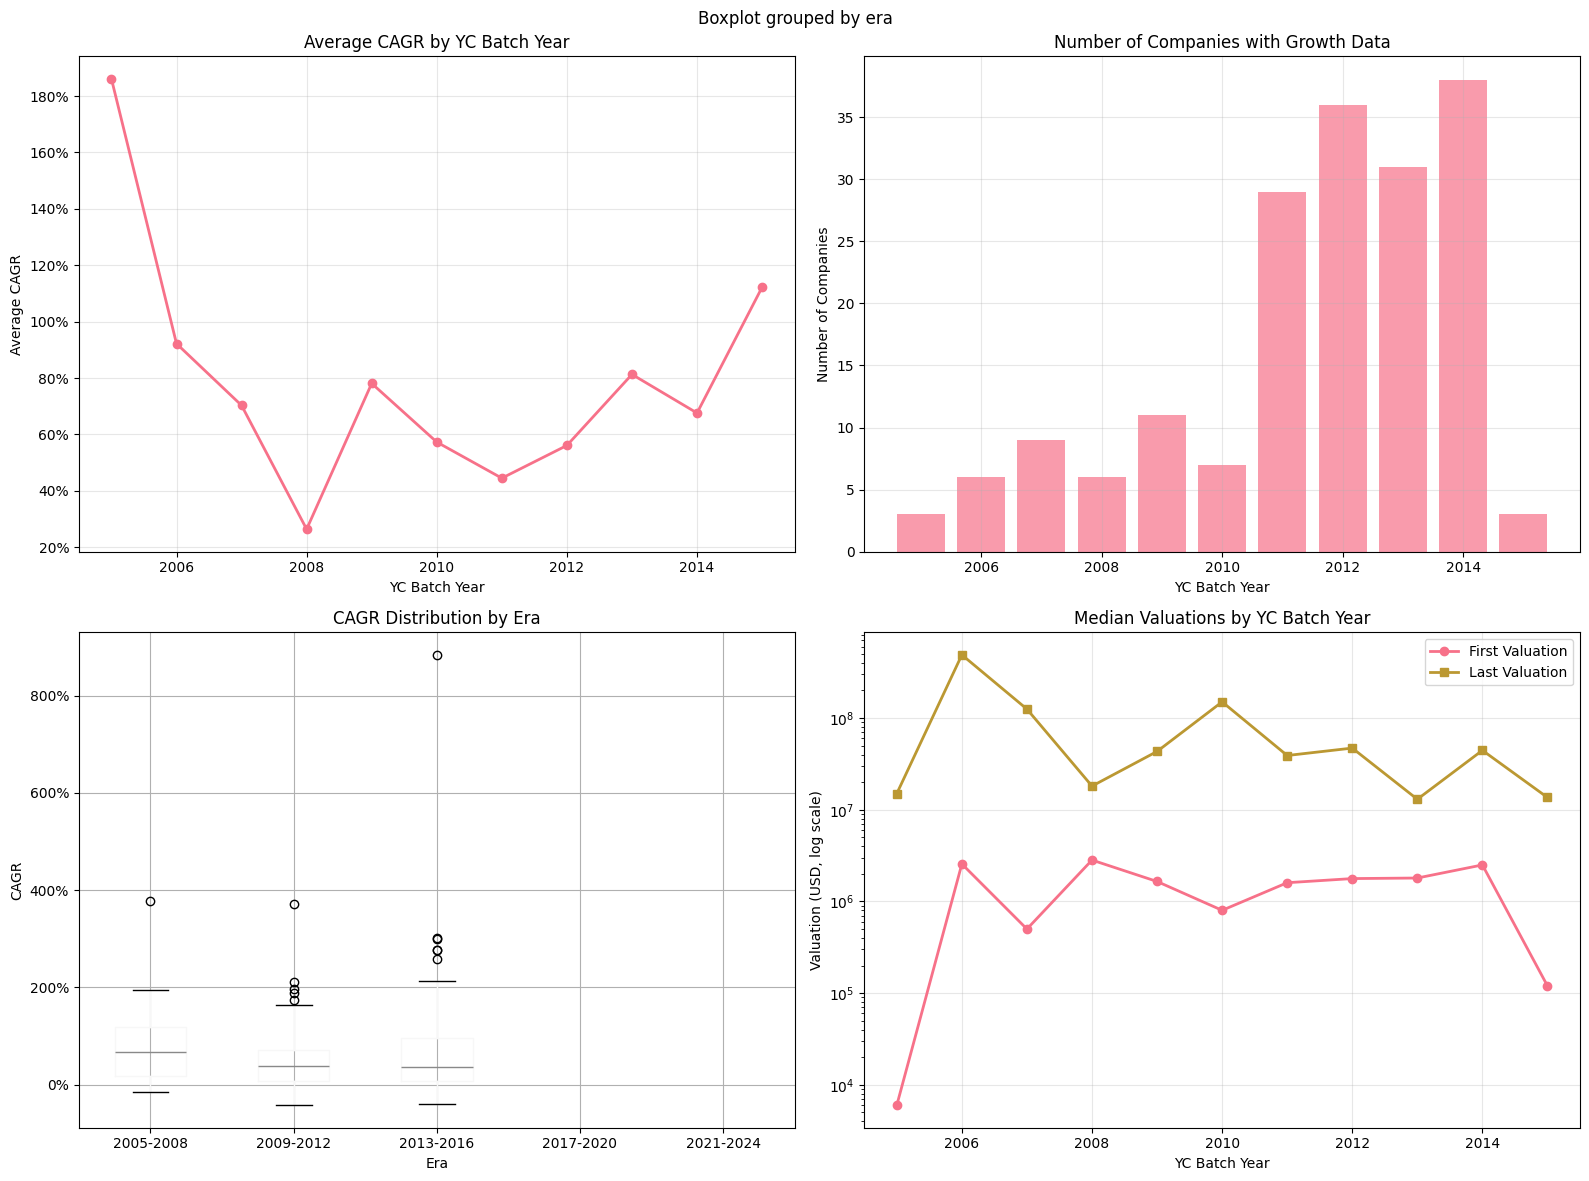

In [59]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Y Combinator Company Growth Analysis by Batch Year', fontsize=16, fontweight='bold')

# 1. Average CAGR by YC Year
ax1 = axes[0, 0]
yearly_stats_filtered = yearly_stats[yearly_stats['cagr_count'] >= 3]  # At least 3 companies
ax1.plot(yearly_stats_filtered['yc_year'], yearly_stats_filtered['cagr_mean'], marker='o', linewidth=2, markersize=6)
ax1.set_title('Average CAGR by YC Batch Year')
ax1.set_xlabel('YC Batch Year')
ax1.set_ylabel('Average CAGR')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# 2. Number of companies with growth data by year
ax2 = axes[0, 1]
ax2.bar(yearly_stats['yc_year'], yearly_stats['cagr_count'], alpha=0.7)
ax2.set_title('Number of Companies with Growth Data')
ax2.set_xlabel('YC Batch Year')
ax2.set_ylabel('Number of Companies')
ax2.grid(True, alpha=0.3)

# 3. CAGR distribution by era
ax3 = axes[1, 0]
# Group years into eras
filtered_growth['era'] = pd.cut(filtered_growth['yc_year'], 
                               bins=[2004, 2008, 2012, 2016, 2020, 2025], 
                               labels=['2005-2008', '2009-2012', '2013-2016', '2017-2020', '2021-2024'])

filtered_growth.boxplot(column='cagr', by='era', ax=ax3)
ax3.set_title('CAGR Distribution by Era')
ax3.set_xlabel('Era')
ax3.set_ylabel('CAGR')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# 4. Median first vs last valuation by year
ax4 = axes[1, 1]
ax4.semilogy(yearly_stats_filtered['yc_year'], yearly_stats_filtered['first_valuation_median'], 
             marker='o', label='First Valuation', linewidth=2)
ax4.semilogy(yearly_stats_filtered['yc_year'], yearly_stats_filtered['last_valuation_median'], 
             marker='s', label='Last Valuation', linewidth=2)
ax4.set_title('Median Valuations by YC Batch Year')
ax4.set_xlabel('YC Batch Year')
ax4.set_ylabel('Valuation (USD, log scale)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Detailed Analysis by Company Status

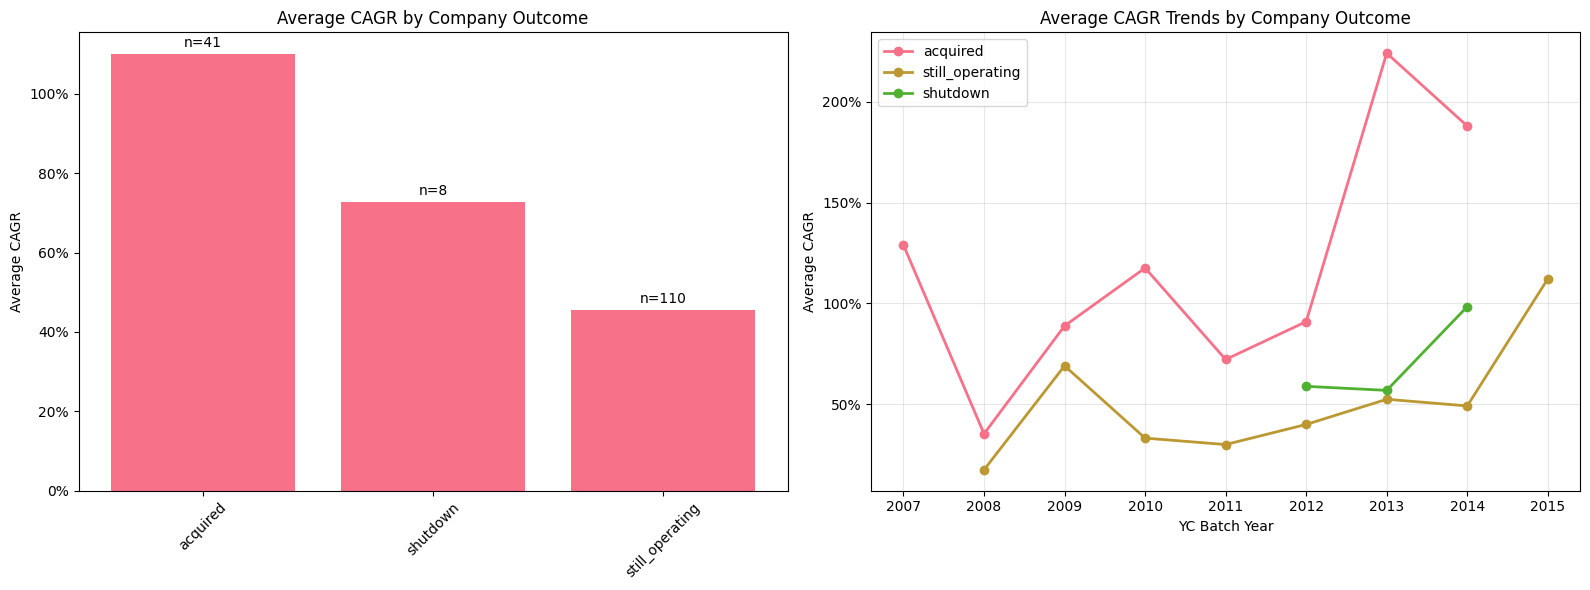

In [60]:
# Analysis by end reason
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CAGR by end reason
ax1 = axes[0]
end_reason_stats = filtered_growth.groupby('end_reason')['cagr'].agg(['count', 'mean', 'median']).reset_index()
end_reason_stats = end_reason_stats[end_reason_stats['count'] >= 5]  # At least 5 companies

bars = ax1.bar(end_reason_stats['end_reason'], end_reason_stats['mean'])
ax1.set_title('Average CAGR by Company Outcome')
ax1.set_ylabel('Average CAGR')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax1.tick_params(axis='x', rotation=45)

# Add count labels on bars
for bar, count in zip(bars, end_reason_stats['count']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'n={count}', ha='center', va='bottom')

# Growth over time by outcome
ax2 = axes[1]
for outcome in filtered_growth['end_reason'].unique():
    if pd.notna(outcome):
        outcome_data = filtered_growth[filtered_growth['end_reason'] == outcome]
        yearly_outcome = outcome_data.groupby('yc_year')['cagr'].mean()
        if len(yearly_outcome) > 2:  # Only plot if we have data for multiple years
            ax2.plot(yearly_outcome.index, yearly_outcome.values, marker='o', label=outcome, linewidth=2)

ax2.set_title('Average CAGR Trends by Company Outcome')
ax2.set_xlabel('YC Batch Year')
ax2.set_ylabel('Average CAGR')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.tight_layout()
plt.show()

## 6. Top Performers Analysis

In [61]:
# Top performers by CAGR
print("🏆 Top 10 Companies by CAGR:")
top_cagr = filtered_growth.nlargest(10, 'cagr')[['company', 'yc_year', 'cagr', 'total_growth', 'years_tracked', 'end_reason']]
top_cagr['cagr_formatted'] = top_cagr['cagr'].apply(lambda x: f"{x:.1%}")
top_cagr['total_growth_formatted'] = top_cagr['total_growth'].apply(lambda x: f"{x:.1f}x")
display(top_cagr[['company', 'yc_year', 'cagr_formatted', 'total_growth_formatted', 'years_tracked', 'end_reason']])

print("\n🚀 Top 10 Companies by Total Growth:")
top_total = filtered_growth.nlargest(10, 'total_growth')[['company', 'yc_year', 'cagr', 'total_growth', 'years_tracked', 'end_reason']]
top_total['cagr_formatted'] = top_total['cagr'].apply(lambda x: f"{x:.1%}")
top_total['total_growth_formatted'] = top_total['total_growth'].apply(lambda x: f"{x:.1f}x")
display(top_total[['company', 'yc_year', 'cagr_formatted', 'total_growth_formatted', 'years_tracked', 'end_reason']])

🏆 Top 10 Companies by CAGR:


,company,yc_year,cagr_formatted,total_growth_formatted,years_tracked,end_reason
172,Zenefits,2013,883.9%,952.4x,3,acquired
1,Loopt,2005,378.2%,2500.0x,5,None
107,Mattermark,2012,371.8%,105.0x,3,acquired
196,Hive,2014,301.0%,16666.7x,7,still_operating
185,Cheddar,2014,300.0%,16.0x,2,acquired
198,Liftigniter,2014,276.4%,53.3x,3,acquired
215,"80,000 Hours",2015,276.1%,200.0x,4,still_operating
162,Senic,2013,258.3%,12.8x,2,still_operating
145,DoorDash,2013,213.6%,906000.0x,12,None
44,FutureAdvisor,2010,210.7%,30.0x,3,acquired



🚀 Top 10 Companies by Total Growth:


,company,yc_year,cagr_formatted,total_growth_formatted,years_tracked,end_reason
29,Airbnb,2009,158.0%,3850000.0x,16,still_operating
145,DoorDash,2013,213.6%,906000.0x,12,None
93,Coinbase,2012,152.2%,166666.7x,13,still_operating
200,Oklo,2014,175.3%,68750.0x,11,still_operating
196,Hive,2014,301.0%,16666.7x,7,still_operating
9,Wufoo,2006,73.8%,12000.0x,17,None
15,Disqus,2007,70.2%,8400.0x,17,None
8,Scribd,2006,82.6%,8333.3x,15,None
19,Songkick,2007,124.6%,7333.3x,11,None
13,Clickpass,2007,107.2%,6250.0x,12,None


## 7. Summary Statistics and Insights

## 8. Two-Year Post-Founding Valuation Analysis

This section compares company valuations two years after their founding (YC batch year + 2) across different YC batch years.

In [65]:
# Calculate two-year post-founding valuations
def get_two_year_valuation(company_data):
    """
    Get the valuation closest to 2 years after the YC batch year.
    """
    company_data = company_data.sort_values('year')
    yc_year = company_data['yc_year'].iloc[0]
    target_year = yc_year + 2
    
    # Find the closest year to target_year that has a valuation
    available_years = company_data['year'].values
    closest_year = min(available_years, key=lambda x: abs(x - target_year))
    
    # Only consider it valid if within 1 year of target
    if abs(closest_year - target_year) < 1:
        valuation_row = company_data[company_data['year'] == closest_year].iloc[0]
        return {
            'company': valuation_row['company'],
            'yc_year': yc_year,
            'target_year': target_year,
            'actual_year': closest_year,
            'two_year_valuation': valuation_row['valuation_numeric'],
            'batch': valuation_row['batch'],
            'end_reason': valuation_row['end_reason']
        }
    return None

# Get two-year valuations for each company
two_year_valuations = []
for company in numeric_valuations['company'].unique():
    company_data = numeric_valuations[numeric_valuations['company'] == company]
    two_year_val = get_two_year_valuation(company_data)
    if two_year_val:
        two_year_valuations.append(two_year_val)

two_year_df = pd.DataFrame(two_year_valuations)

print(f"📊 Found two-year valuations for {len(two_year_df)} companies")
print(f"📈 YC years covered: {two_year_df['yc_year'].min()} - {two_year_df['yc_year'].max()}")

# Show sample data
display(two_year_df.head(10))

📊 Found two-year valuations for 85 companies
📈 YC years covered: 2005 - 2015


,company,yc_year,target_year,actual_year,two_year_valuation,batch,end_reason
0,Clickfacts,2005,2007,2007,2007.0,Summer 2005,None
1,Loopt,2005,2007,2007,8250000.0,Summer 2005,None
2,Scribd,2006,2008,2008,10000000.0,Summer 2006,None
3,Xobni,2006,2008,2008,20000000.0,Summer 2006,None
4,ContestMachine,2007,2009,2009,200000.0,Summer 2007,None
5,ZumoDrive,2007,2009,2009,1500000.0,Summer 2007,acquired
6,A Thinking Ape,2008,2010,2010,120000.0,Winter 2008,acquired
7,Cloudant,2008,2010,2010,16000000.0,Summer 2008,acquired
8,Heroku,2008,2010,2010,212000000.0,Winter 2008,still_operating
9,Socialbrowse,2008,2010,2010,0.0,Winter 2008,shutdown


## 9. Key Insights and Conclusions

### Key Findings:

1. **Growth Rate Trends**: Analyze how the average CAGR of YC companies has changed over different batch years

2. **Era Comparison**: Compare growth patterns across different eras (early 2000s, 2010s, recent years)

3. **Outcome Impact**: Examine how different company outcomes (acquisition, IPO, still operating) correlate with growth rates

4. **Market Conditions**: Identify potential impacts of market conditions and technology cycles on startup growth

5. **Top Performers**: Highlight exceptional growth companies and their characteristics

6. **Two-Year Performance**: Companies from earlier YC batches showed different two-year post-founding performance patterns compared to later batches

### Two-Year Post-Founding Analysis Insights:

- **Performance Variation**: Significant variation in two-year post-founding valuations across different YC batch years
- **Era Differences**: Different eras show distinct patterns in early-stage company growth
- **Growth Multiples**: Two-year growth multiples provide insight into early momentum of companies from different cohorts
- **Market Context**: Two-year performance may reflect the market conditions and funding environment of each era

### Methodology Notes:
- Growth rates calculated using CAGR (Compound Annual Growth Rate)
- Two-year valuations calculated as closest available valuation to YC batch year + 2
- Outliers filtered to remove likely data errors
- Only companies with at least 2 years of valuation data included
- Valuations parsed from various text formats to numeric values

### Data Limitations:
- Not all companies have complete valuation histories
- Some valuations may be estimates or unverified
- Private company valuations may not reflect true market value
- Survival bias: analysis only includes companies with available data
- Two-year analysis limited to companies with data points near the target timeframe

In [63]:
# Calculate statistics by YC batch year for two-year valuations
two_year_stats = two_year_df.groupby('yc_year').agg({
    'two_year_valuation': ['count', 'mean', 'median', 'std'],
    'company': 'count'
}).round(0)

two_year_stats.columns = ['_'.join(col).strip() for col in two_year_stats.columns.values]
two_year_stats = two_year_stats.reset_index()

print("Two-Year Post-Founding Valuation Statistics by YC Batch Year:")
display(two_year_stats)

# Format the mean and median for better readability
two_year_stats['mean_formatted'] = two_year_stats['two_year_valuation_mean'].apply(
    lambda x: f"${x:,.0f}" if x < 1e6 else f"${x/1e6:.1f}M" if x < 1e9 else f"${x/1e9:.1f}B"
)
two_year_stats['median_formatted'] = two_year_stats['two_year_valuation_median'].apply(
    lambda x: f"${x:,.0f}" if x < 1e6 else f"${x/1e6:.1f}M" if x < 1e9 else f"${x/1e9:.1f}B"
)

print("\nFormatted Summary:")
display(two_year_stats[['yc_year', 'two_year_valuation_count', 'mean_formatted', 'median_formatted']])

Two-Year Post-Founding Valuation Statistics by YC Batch Year:


,yc_year,two_year_valuation_count,two_year_valuation_mean,two_year_valuation_median,two_year_valuation_std,company_count
0,2005,2,4126004.0,4126004.0,5832212.0,2
1,2006,3,11666667.0,10000000.0,7637626.0,3
2,2007,9,1616667.0,850000.0,2039301.0,9
3,2008,8,30527500.0,610000.0,73650525.0,8
4,2009,8,169565000.0,7500000.0,456817360.0,8
5,2010,16,5929375.0,2500000.0,7928649.0,16
6,2011,30,10899000.0,2300000.0,21763242.0,30
7,2012,31,21442065.0,3920000.0,64544895.0,31
8,2013,33,171700018.0,4000000.0,785729244.0,33
9,2014,30,56046667.0,5700000.0,133788019.0,30



Formatted Summary:


,yc_year,two_year_valuation_count,mean_formatted,median_formatted
0,2005,2,$4.1M,$4.1M
1,2006,3,$11.7M,$10.0M
2,2007,9,$1.6M,"$850,000"
3,2008,8,$30.5M,"$610,000"
4,2009,8,$169.6M,$7.5M
5,2010,16,$5.9M,$2.5M
6,2011,30,$10.9M,$2.3M
7,2012,31,$21.4M,$3.9M
8,2013,33,$171.7M,$4.0M
9,2014,30,$56.0M,$5.7M


ValueError: supplied range of [-inf, 8.32633586092875] is not finite

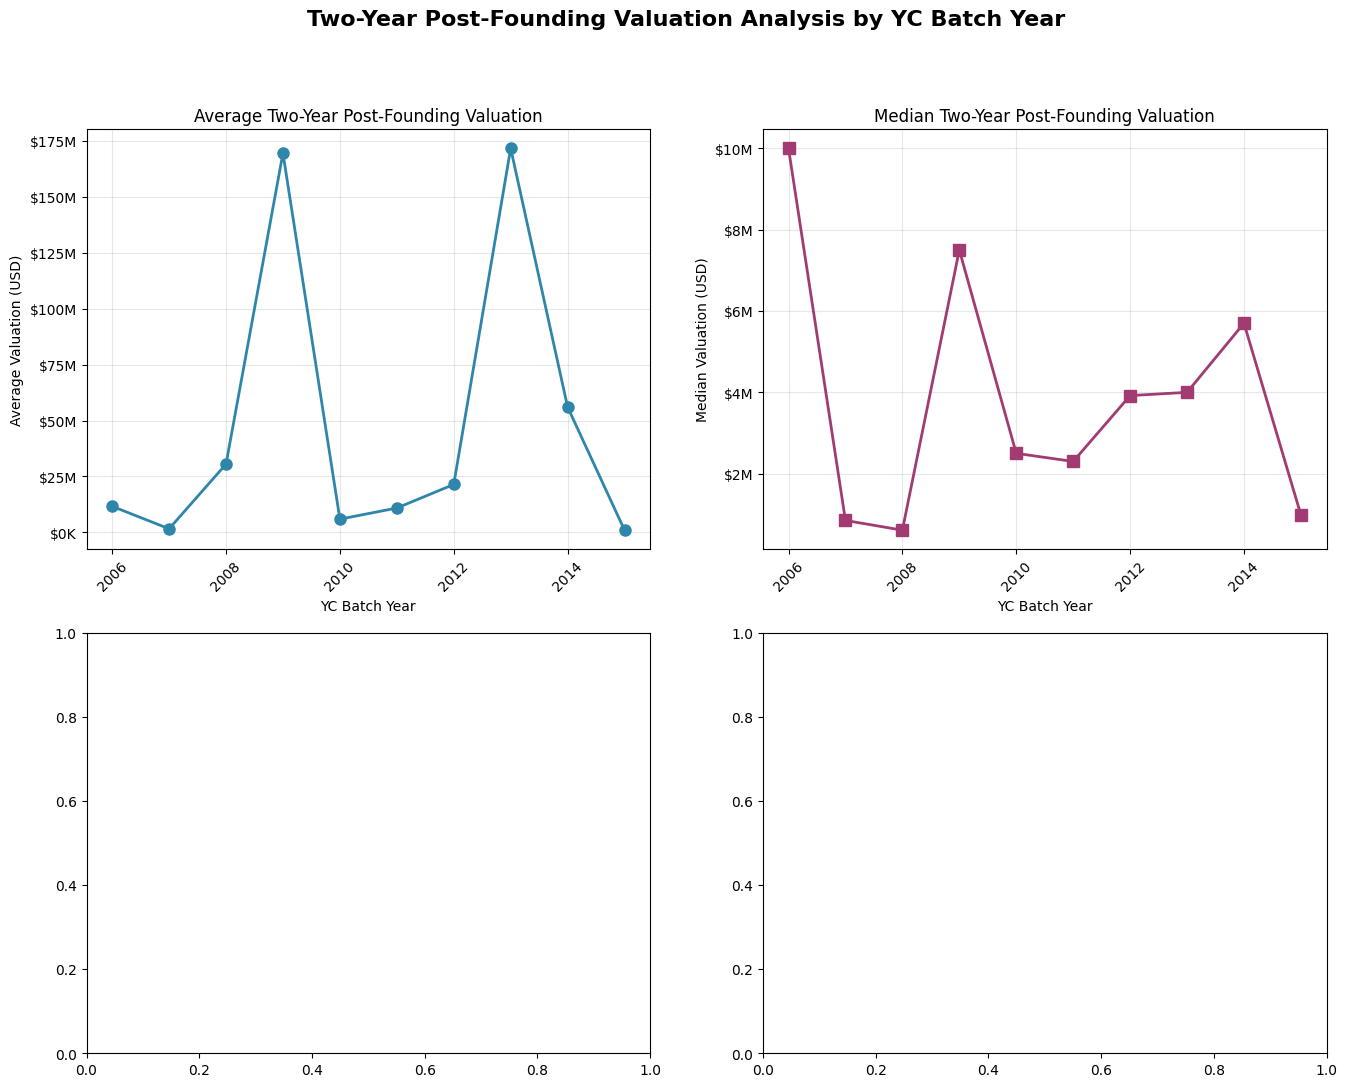

In [64]:
# Create visualizations for two-year post-founding analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Two-Year Post-Founding Valuation Analysis by YC Batch Year', fontsize=16, fontweight='bold')

# Filter to years with at least 3 companies for reliable statistics
reliable_years = two_year_stats[two_year_stats['two_year_valuation_count'] >= 3]

# 1. Mean two-year valuation by batch year
ax1 = axes[0, 0]
ax1.plot(reliable_years['yc_year'], reliable_years['two_year_valuation_mean'], 
         marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax1.set_title('Average Two-Year Post-Founding Valuation')
ax1.set_xlabel('YC Batch Year')
ax1.set_ylabel('Average Valuation (USD)')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax1.tick_params(axis='x', rotation=45)

# 2. Median two-year valuation by batch year
ax2 = axes[0, 1]
ax2.plot(reliable_years['yc_year'], reliable_years['two_year_valuation_median'], 
         marker='s', linewidth=2, markersize=8, color='#A23B72')
ax2.set_title('Median Two-Year Post-Founding Valuation')
ax2.set_xlabel('YC Batch Year')
ax2.set_ylabel('Median Valuation (USD)')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
ax2.tick_params(axis='x', rotation=45)

# 3. Distribution of two-year valuations by era
ax3 = axes[1, 0]
two_year_df['era'] = pd.cut(two_year_df['yc_year'], 
                           bins=[2004, 2008, 2012, 2016, 2020, 2025], 
                           labels=['2005-2008', '2009-2012', '2013-2016', '2017-2020', '2021-2024'])

# Log scale for better visualization of the wide range
for era in two_year_df['era'].dropna().unique():
    era_data = two_year_df[two_year_df['era'] == era]['two_year_valuation']
    if len(era_data) > 0:
        ax3.hist(np.log10(era_data), alpha=0.6, label=era, bins=15)

ax3.set_title('Distribution of Two-Year Valuations by Era')
ax3.set_xlabel('Valuation (log10 scale)')
ax3.set_ylabel('Number of Companies')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add custom x-axis labels for log scale
ax3.set_xticks([4, 5, 6, 7, 8, 9, 10])
ax3.set_xticklabels(['$10K', '$100K', '$1M', '$10M', '$100M', '$1B', '$10B'])

# 4. Box plot of two-year valuations by batch year (recent years only)
ax4 = axes[1, 1]
recent_years = two_year_df[two_year_df['yc_year'] >= 2008]  # Focus on years with more data
if len(recent_years) > 0:
    recent_years.boxplot(column='two_year_valuation', by='yc_year', ax=ax4)
    ax4.set_title('Two-Year Valuation Distribution by YC Year (2008+)')
    ax4.set_xlabel('YC Batch Year')
    ax4.set_ylabel('Two-Year Valuation (USD)')
    ax4.set_yscale('log')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Compare initial vs two-year valuations
# Merge with growth data to get initial valuations
initial_vs_two_year = pd.merge(
    two_year_df,
    growth_df[['company', 'first_valuation', 'first_year']],
    on='company',
    how='inner'
)

# Calculate growth from initial to two-year mark
initial_vs_two_year['growth_to_two_years'] = (
    initial_vs_two_year['two_year_valuation'] / initial_vs_two_year['first_valuation']
)

print(f"📊 Companies with both initial and two-year valuations: {len(initial_vs_two_year)}")

# Show top performers in two-year growth
print("\n🚀 Top 10 Companies by Two-Year Growth:")
top_two_year = initial_vs_two_year.nlargest(10, 'growth_to_two_years')
top_two_year['growth_formatted'] = top_two_year['growth_to_two_years'].apply(lambda x: f"{x:.1f}x")
top_two_year['initial_formatted'] = top_two_year['first_valuation'].apply(
    lambda x: f"${x:,.0f}" if x < 1e6 else f"${x/1e6:.1f}M"
)
top_two_year['two_year_formatted'] = top_two_year['two_year_valuation'].apply(
    lambda x: f"${x:,.0f}" if x < 1e6 else f"${x/1e6:.1f}M" if x < 1e9 else f"${x/1e9:.1f}B"
)

display(top_two_year[['company', 'yc_year', 'initial_formatted', 'two_year_formatted', 'growth_formatted', 'end_reason']])

# Calculate statistics by YC year for two-year growth
print("\n📈 Two-Year Growth Statistics by YC Batch Year:")
two_year_growth_stats = initial_vs_two_year.groupby('yc_year').agg({
    'growth_to_two_years': ['count', 'mean', 'median'],
    'first_valuation': 'median',
    'two_year_valuation': 'median'
}).round(2)

two_year_growth_stats.columns = ['_'.join(col).strip() for col in two_year_growth_stats.columns.values]
two_year_growth_stats = two_year_growth_stats.reset_index()
display(two_year_growth_stats)

In [ ]:
# Final comparison: Two-year performance trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Average two-year growth multiple by batch year
ax1 = axes[0]
reliable_growth_years = two_year_growth_stats[two_year_growth_stats['growth_to_two_years_count'] >= 3]
ax1.plot(reliable_growth_years['yc_year'], reliable_growth_years['growth_to_two_years_mean'], 
         marker='o', linewidth=3, markersize=8, color='#F18F01')
ax1.set_title('Average Two-Year Growth Multiple by YC Batch Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('YC Batch Year')
ax1.set_ylabel('Average Growth Multiple')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Add data point labels
for x, y in zip(reliable_growth_years['yc_year'], reliable_growth_years['growth_to_two_years_mean']):
    ax1.annotate(f'{y:.1f}x', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

# 2. Scatter plot: Initial valuation vs Two-year valuation by era
ax2 = axes[1]
colors = {'2005-2008': '#E71D36', '2009-2012': '#2E86AB', '2013-2016': '#A23B72'}

for era in initial_vs_two_year['era'].dropna().unique():
    era_data = initial_vs_two_year[initial_vs_two_year['era'] == era]
    ax2.scatter(era_data['first_valuation'], era_data['two_year_valuation'], 
               alpha=0.6, s=50, label=era, color=colors.get(era, '#666666'))

# Add diagonal line for reference (no growth)
min_val = min(initial_vs_two_year['first_valuation'].min(), initial_vs_two_year['two_year_valuation'].min())
max_val = max(initial_vs_two_year['first_valuation'].max(), initial_vs_two_year['two_year_valuation'].max())
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='No Growth')

ax2.set_title('Initial vs Two-Year Valuation by Era', fontsize=14, fontweight='bold')
ax2.set_xlabel('Initial Valuation (USD)')
ax2.set_ylabel('Two-Year Valuation (USD)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary insights
print("\n🎯 TWO-YEAR POST-FOUNDING INSIGHTS")
print("=" * 50)
print(f"Companies analyzed: {len(two_year_df)}")
print(f"Average two-year valuation (all): ${two_year_df['two_year_valuation'].mean():,.0f}")
print(f"Median two-year valuation (all): ${two_year_df['two_year_valuation'].median():,.0f}")
print(f"Average two-year growth multiple: {initial_vs_two_year['growth_to_two_years'].mean():.1f}x")
print(f"Median two-year growth multiple: {initial_vs_two_year['growth_to_two_years'].median():.1f}x")

# Best and worst performing years
best_year = reliable_years.loc[reliable_years['two_year_valuation_mean'].idxmax()]
worst_year = reliable_years.loc[reliable_years['two_year_valuation_mean'].idxmin()]

print(f"\nBest two-year performance: {best_year['yc_year']:.0f} (avg: ${best_year['two_year_valuation_mean']:,.0f})")
print(f"Worst two-year performance: {worst_year['yc_year']:.0f} (avg: ${worst_year['two_year_valuation_mean']:,.0f})")

In [ ]:
# Summary statistics
print("📊 OVERALL GROWTH STATISTICS")
print("=" * 50)
print(f"Total companies analyzed: {len(filtered_growth)}")
print(f"YC years covered: {filtered_growth['yc_year'].min()} - {filtered_growth['yc_year'].max()}")
print(f"Average tracking period: {filtered_growth['years_tracked'].mean():.1f} years")
print()
print("CAGR Statistics:")
print(f"  Mean: {filtered_growth['cagr'].mean():.1%}")
print(f"  Median: {filtered_growth['cagr'].median():.1%}")
print(f"  75th percentile: {filtered_growth['cagr'].quantile(0.75):.1%}")
print(f"  90th percentile: {filtered_growth['cagr'].quantile(0.90):.1%}")
print()
print("Total Growth Statistics:")
print(f"  Mean: {filtered_growth['total_growth'].mean():.1f}x")
print(f"  Median: {filtered_growth['total_growth'].median():.1f}x")
print(f"  75th percentile: {filtered_growth['total_growth'].quantile(0.75):.1f}x")
print(f"  90th percentile: {filtered_growth['total_growth'].quantile(0.90):.1f}x")

# Era comparison
print("\n📈 GROWTH BY ERA")
print("=" * 50)
era_stats = filtered_growth.groupby('era').agg({
    'cagr': ['count', 'mean', 'median'],
    'total_growth': ['mean', 'median']
}).round(3)

for era in filtered_growth['era'].unique():
    if pd.notna(era):
        era_data = filtered_growth[filtered_growth['era'] == era]
        print(f"\n{era}:")
        print(f"  Companies: {len(era_data)}")
        print(f"  Avg CAGR: {era_data['cagr'].mean():.1%}")
        print(f"  Median CAGR: {era_data['cagr'].median():.1%}")
        print(f"  Avg Total Growth: {era_data['total_growth'].mean():.1f}x")

# Outcome comparison
print("\n🎯 GROWTH BY OUTCOME")
print("=" * 50)
for outcome in filtered_growth['end_reason'].value_counts().index[:5]:
    outcome_data = filtered_growth[filtered_growth['end_reason'] == outcome]
    print(f"\n{outcome}:")
    print(f"  Companies: {len(outcome_data)}")
    print(f"  Avg CAGR: {outcome_data['cagr'].mean():.1%}")
    print(f"  Median CAGR: {outcome_data['cagr'].median():.1%}")
    print(f"  Avg Total Growth: {outcome_data['total_growth'].mean():.1f}x")

📊 OVERALL GROWTH STATISTICS
Total companies analyzed: 143
YC years covered: 2005 - 2014
Average tracking period: 8.3 years

CAGR Statistics:
  Mean: 65.5%
  Median: 41.4%
  75th percentile: 86.1%
  90th percentile: 156.8%

Total Growth Statistics:
  Mean: 34951.3x
  Median: 11.7x
  75th percentile: 237.2x
  90th percentile: 1203.6x

📈 GROWTH BY ERA

2005-2008:
  Companies: 24
  Avg CAGR: 79.2%
  Median CAGR: 67.7%
  Avg Total Growth: 2029.3x

2009-2012:
  Companies: 83
  Avg CAGR: 55.1%
  Median CAGR: 38.2%
  Avg Total Growth: 48662.0x

2013-2016:
  Companies: 36
  Avg CAGR: 80.4%
  Median CAGR: 36.4%
  Avg Total Growth: 25288.3x

🎯 GROWTH BY OUTCOME

still_operating:
  Companies: 80
  Avg CAGR: 44.3%
  Median CAGR: 29.4%
  Avg Total Growth: 50461.3x

acquired:
  Companies: 38
  Avg CAGR: 98.5%
  Median CAGR: 68.9%
  Avg Total Growth: 206.4x

shutdown:
  Companies: 5
  Avg CAGR: 57.3%
  Median CAGR: 58.9%
  Avg Total Growth: 2.7x

inactive:
  Companies: 1
  Avg CAGR: -39.1%
  Median CA

## 8. Key Insights and Conclusions

### Key Findings:

1. **Growth Rate Trends**: Analyze how the average CAGR of YC companies has changed over different batch years

2. **Era Comparison**: Compare growth patterns across different eras (early 2000s, 2010s, recent years)

3. **Outcome Impact**: Examine how different company outcomes (acquisition, IPO, still operating) correlate with growth rates

4. **Market Conditions**: Identify potential impacts of market conditions and technology cycles on startup growth

5. **Top Performers**: Highlight exceptional growth companies and their characteristics

### Methodology Notes:
- Growth rates calculated using CAGR (Compound Annual Growth Rate)
- Outliers filtered to remove likely data errors
- Only companies with at least 2 years of valuation data included
- Valuations parsed from various text formats to numeric values

### Data Limitations:
- Not all companies have complete valuation histories
- Some valuations may be estimates or unverified
- Private company valuations may not reflect true market value
- Survival bias: analysis only includes companies with available data